In [6]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

import operator
from typing_extensions import Annotated

from langgraph.graph.message import add_messages

import os
from dotenv import load_dotenv

# ~/.bashrc에서 환경변수를 불러오기
load_dotenv(os.path.expanduser("~/.bashrc"))

Python-dotenv could not parse statement starting at line 6
Python-dotenv could not parse statement starting at line 7
Python-dotenv could not parse statement starting at line 8
Python-dotenv could not parse statement starting at line 16
Python-dotenv could not parse statement starting at line 24
Python-dotenv could not parse statement starting at line 31
Python-dotenv could not parse statement starting at line 34
Python-dotenv could not parse statement starting at line 39
Python-dotenv could not parse statement starting at line 40
Python-dotenv could not parse statement starting at line 47
Python-dotenv could not parse statement starting at line 49
Python-dotenv could not parse statement starting at line 58
Python-dotenv could not parse statement starting at line 64
Python-dotenv could not parse statement starting at line 67
Python-dotenv could not parse statement starting at line 76
Python-dotenv could not parse statement starting at line 77
Python-dotenv could not parse statement sta

True

### 1. 아주 간단한 랭그래프

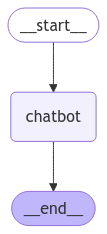

{'counter': 1, 'alphabet': ['Hello']}
{'counter': 1, 'alphabet': ['Hello']}
{'counter': 1, 'alphabet': ['Hello']}


In [ ]:
class State(TypedDict):
    counter: int
    alphabet: list[str]

def node_a(state: State):
    state['counter'] += 1
    state['alphabet'] = ['Hello']
    return state

graph_builder = StateGraph(State)

graph_builder.add_node("chatbot", node_a)

graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)

graph = graph_builder.compile()  # 그래프를 실행 가능한 객체로 만들어주기

try:  # 시각화 (컴파일 한 후에 실행 해야함)
    display(Image(graph.get_graph().draw_mermaid_png()))
except:
    pass

# 테스트
initial_state = {"counter": 0, "alphabet": ["init"]}
for _ in range(3):
    state = graph.invoke(initial_state)
    print(state)

### 2. context 활용하기

- 그래프 내에서만 유지되는 context 임

In [ ]:
class State(TypedDict):
    counter: int
    alphabet: Annotated[list[str], operator.add]

def node_a(state: State):
    state['counter'] += 1
    state['alphabet'] = ['Hello']
    return state

graph_builder = StateGraph(State)

graph_builder.add_node("chatbot", node_a)

graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)

graph = graph_builder.compile()  # 그래프를 실행 가능한 객체로 만들어주기

try:  # 시각화 (컴파일 한 후에 실행 해야함)
    display(Image(graph.get_graph().draw_mermaid_png()))
except:
    pass

# 테스트
initial_state = {"counter": 0, "alphabet": ["init"]}
state = initial_state
for _ in range(3):
    state = graph.invoke(state)
    print(state)

{'counter': 1, 'alphabet': ['init', 'Hello']}
{'counter': 2, 'alphabet': ['init', 'Hello', 'Hello']}
{'counter': 3, 'alphabet': ['init', 'Hello', 'Hello', 'Hello']}


### 3. message 를 담는 StateGraph

- LLM 이 보내는 답변이나 LLM 에게 보내는 메세지를 state에 담아서 보낼 때 사용
- add_messages 모듈은 랭그래프에서 사전 정의된 모듈로 operator.add 의 메세지 버전이라고 생각하면 됨

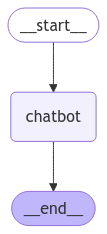

RateLimitError: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}

In [9]:
from langchain_openai import ChatOpenAI


class State(TypedDict):
    messages: Annotated[list[str], add_messages]

def node_a(state: State):
    # state 의 messages 값을 그대로 llm 에게 넘겨서 답변 결과를 messages 로 다시 업데이트
    return {"messages": [llm.invoke(state['messages'])]}

graph_builder = StateGraph(State)

llm = ChatOpenAI(model = "gpt-4o-mini")

graph_builder.add_node("chatbot", node_a)

graph_builder.set_entry_point("chatbot")  # START 와 연결
graph_builder.set_finish_point("chatbot")  # END 와 연결

graph = graph_builder.compile()  # 그래프를 실행 가능한 객체로 만들어주기

try:  # 시각화 (컴파일 한 후에 실행 해야함)
    display(Image(graph.get_graph().draw_mermaid_png()))
except:
    pass

# 테스트
while True:
    user_input = input("User: ")
    if user_input.lower() in ["quit", "exit", "q"]:
        print("Goodbye")
        break
    # invoke 가 아닌 stream 을 하면 대화의 새로운 상태를 한 턴 씩 계속 보여줌
    for event in graph.stream({"messages": ("user", user_input)}):
        for value in event.values():
            print("Assistant:", value["messages"][-1].content)

### 3-1. MessageState 로 손쉽게 구현

- 위에서 사용했던 Annotated[list[str], add_messages] 를 래핑해서 제공해줌
- 단순한 형태의 챗봇에서 사용 가능

In [ ]:
from langgraph.graph import MessagesState

graph_builder = StateGraph(MessagesState)

llm = ChatOpenAI(model = "gpt-4o-mini")

def node_a(state: State):
    # state 의 messages 값을 그대로 llm 에게 넘겨서 답변 결과를 messages 로 다시 업데이트
    return {"messages": [llm.invoke(state['messages'])]}

graph_builder.add_node("chatbot", node_a)

graph_builder.set_entry_point("chatbot")  # START 와 연결
graph_builder.set_finish_point("chatbot")  # END 와 연결

graph = graph_builder.compile()  # 그래프를 실행 가능한 객체로 만들어주기

# 테스트
while True:
    user_input = input("User: ")
    if user_input.lower() in ["quit", "exit", "q"]:
        print("Goodbye")
        break
    # invoke 가 아닌 stream 을 하면 대화의 새로운 상태를 한 턴 씩 계속 보여줌
    for event in graph.stream({"messages": ("user", user_input)}):
        for value in event.values():
            print("Assistant:", value["messages"][-1].content)

### 3-2. MessagesState 에 다른 변수 주가해서 사용하기

- MessagesState 오버라이딩하면 됨

In [ ]:
class State(MessagesState):
    counter: int  # 새로운 속성 추가

graph_builder = StateGraph(State)

llm = ChatOpenAI(model = "gpt-4o-mini")

def node_a(state: State):
    state['counter'] = state.get('counter', 0) + 1  # 새로운 속성도 추가해야 함
    return {
        "messages": [llm.invoke(state['messages'])],
        "counter": state['counter']}

graph_builder.add_node("chatbot", node_a)

graph_builder.set_entry_point("chatbot")  # START 와 연결
graph_builder.set_finish_point("chatbot")  # END 와 연결

graph = graph_builder.compile()  # 그래프를 실행 가능한 객체로 만들어주기

# 테스트
from langchain_core.messages import HumanMessage
initial_state = {"counter": 0, "messages": [HumanMessage(content="Hello Hi")]}
state = initial_state
for _ in range(3):
    state = graph.invoke(state)
    print(f"Counter: {state['counter']}")
    print(f"Last message: {state['messages'][-1].content}")
    print("...")

### 4. Tool을 활용하는 기본적인 에이전트 설계

- 에이전트가 직접 답변하기 어려운 부분은 도구를 활용하여 답변하도록 설계
- 그렇지 않으면 에이전트가 모르는 부분을 모른다고 답변하지 않고 hallucination 현상이 생기게 됨

AI 모델은 사용자의 질문을 분석하여 도구를 활용할 필요가 있는 경우 "tool_calls" 속성을 생성하고, 그렇지 않은 경우 아무 값도 출력하지 않는다
"tool_calls" 속성은 필요한 도구의 이름과 속성을 포함하며, AI가 이를 바탕으로 어떤 도구에 질문을 보내야 하는지 및 전달할 입력값을 결정한다
컨디셔널 엣지와 "should_continue" 함수는 도구의 활용 필요 여부에 따라 AI 메시지를 분기하여 적합한 도구를 호출하도록 설정한다
AI는 주어진 질문에 대해 도구 간의 올바른 통신을 설정하고, 툴 노드를 통해 기타 도구에서 실행한 결과를 반환받아 사용자에게 정확한 답변을 제공한다
복잡한 질문에도 불구하고 여러 도구를 결합하여 툴 노드를 실행함으로써 완벽한 답변을 제공하며, 향후 웹 검색 등의 도구를 추가적으로 활용할 계획이다

In [4]:
from langchain_core.messages import AIMessage
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode

# tool 로 활용하기 위해서는 tool decorator 를 달아주면 됨
def get_weather(location: str):
    """call to get weather"""
    if location in ['서울', '인천']:
        return '날씨는 좋다'
    else:
        return '날씨 구리다'
    
@tool
def get_coolest_cities():
    """call to get coolest cities"""
    return '서울, 고성'

tools = [get_weather, get_coolest_cities]
tool_node = ToolNode(tools)  # tool을 그래프 내에서 활용할 수 있는 노드로 변환

from langchain_openai import ChatOpenAI
model_with_tools = ChatOpenAI(model="gpt-4o-mini", temperature=0).bind_tools(tools)

# 테스트
# 사용자에게 받은 질문이 도구를 활용할 수 있다면 tool_calls 속성이 생김
print(model_with_tools.invoke("서울 날씨는 어때?").tool_calls)
print(model_with_tools.invoke("한국에서 가장 추운 도시는?").tool_calls)
# 그렇지 않으면 아무것도 내뱉지 않음 
print(model_with_tools.invoke("오늘 날짜 며칠이야?").tool_calls)

# tool node에 tool call 을 보냈을 때 결과 확인 
tool_node.invoke({"messages": [model_with_tools.invoke("서울 날씨는 어때?")]})

RateLimitError: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}

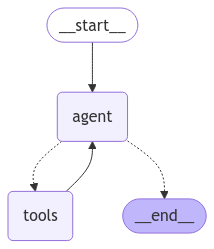

RateLimitError: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}

In [8]:
from typing import Annotated, Literal, TypedDict
from langchain_core.messages import HumanMessage
from langchain_core.tools import tool
from langgraph.graph import END, START, StateGraph, MessagesState

def should_continue(state: MessagesState) -> Literal["tools", END]:
    messages = state['messages']
    last_message = messages[-1]
    if last_message.tool_calls:  # 도구를 불러야 하는 요청이면
        return "tools"
    return END

def call_model(state: MessagesState):
    # 메세지가 들어왔을 때 tool 이 있다는 것을 인지하고 있는 모델에게 메세지를 전달
    messages = state['messages']
    response = model_with_tools.invoke(messages)
    return {"messages": [response]}

workflow = StateGraph(MessagesState)

workflow.add_node("agent", call_model)
workflow.add_node("tools", tool_node)

workflow.add_edge(START, "agent")
workflow.add_conditional_edges("agent", should_continue,)

workflow.add_edge("tools", "agent") # 도구는 결과를 무조건 에이전트에게 보내야 함

app = workflow.compile()

try:  # 시각화 (컴파일 한 후에 실행 해야함)
    display(Image(app.get_graph().draw_mermaid_png()))
except:
    pass

final_state = app.invoke({"messages": [HumanMessage(content="서울 날씨는 어떄?")]})
final_state['messages'][-1].content

In [ ]:
for chunk in app.stream({"messages": [("human", "가장 추운 도시의 날씨는 어때?")]}, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

### 5. 웹 검색 에이전트 만들기

- Tavily: 특정 키워드에 대해 LLM 이 받아들이기 편리한 형태로 웹 검색 결과를 가져오는 라이브러리

In [ ]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages
from langchain_community.tools.tavily_search import TavilySearchResults
from langgraph.prebuilt import ToolNode, tools_condition

class State(TypedDict):
    messages: Annotated[list, add_messages]

# tool node
tool = TavilySearchResults(max_results=2) # 최대 2개의 웹 검색 결과 가져옴
tools = [tool]
tool_node = ToolNode(tools)

llm = ChatOpenAI(model='gpt-4o-mini')
llm_with_tools = llm.bind_tools(tools)

def chatbot(state: State):
    result = llm_with_tools.invoke(state['messages'])
    return result

graph_builder = StateGraph(State)

graph_builder.add_node("chatbot", chatbot)
graph_builder.add_node("tools", tool_node)

graph_builder.add_edge("tools", "chatbot")
graph_builder.add_conditional_edges("chatbot", tools_condition)

graph_builder.set_entry_point("chatbot")
graph = graph_builder.compile()

# 인터넷 검색이 필요한 질문 
graph.invoke({'messages': {'role': 'user', 'content': '지금 한국 대통령은 누구야?'}})

# llm 이 대답할 수 있는 질문
graph.invoke({'messages': {'role': 'user', 'content': '구글은 뭐하는 회사야?'}})